# 연기, 불꽃 실시간 탐지를 통한 산불 조기 경보 시스템

### 파트 나 YOLO 모델 시각화

라이브러리 import

In [29]:
import os
import glob
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

from ultralytics import YOLO

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
random.seed(42)

경로 설정

In [ ]:
IMAGE_DIR = 'dataset/data/val/images'
LABEL_DIR = 'dataset/data/val/labels'   # 라벨 있으면 사용
RESULTS_CSV = 'basic_YOLO.csv'          # baseline 학습 곡선용

MODEL_PATHS = {
    'baseline_pt': 'best_basic.pt',
    'opt_pt': 'best_kaggle.pt',
    'onnx_fp32': 'best_general.onnx',
    'onnx_int8': 'best_int8.onnx',
    # TensorRT engine은 GPU/TensorRT 환경일 때만
    #'trt_fp16': 'best_gpu.engine'
}

CLASS_NAMES = {
    0: 'fire',
    1: 'smoke'
}

SAVE_DIR = Path('compare_outputs')
SAVE_DIR.mkdir(exist_ok=True)

모델 로드

In [3]:
models = {}

for model_name, model_path in MODEL_PATHS.items():
    try:
        models[model_name] = YOLO(model_path)
        print(f'로드 성공: {model_name}')
    except Exception as e:
        print(f'로드 실패: {model_name} -> {e}')

로드 성공: baseline_pt
로드 성공: opt_pt
WARNING Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
로드 성공: onnx_fp32
WARNING Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
로드 성공: onnx_int8


이미지 목록

In [4]:
image_paths = glob.glob(os.path.join(IMAGE_DIR, '*.jpg'))
image_paths += glob.glob(os.path.join(IMAGE_DIR, '*.jpeg'))
image_paths += glob.glob(os.path.join(IMAGE_DIR, '*.png'))

print(f'총 이미지 수: {len(image_paths)}')

총 이미지 수: 3099


사용자 정의 함수

In [5]:
def load_yolo_labels(label_path):
    boxes = []
    if not os.path.exists(label_path):
        return boxes

    with open(label_path, 'r') as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 5:
            continue

        cls_id = int(parts[0])
        x_center, y_center, w, h = map(float, parts[1:5])

        boxes.append({
            'class_id': cls_id,
            'class_name': CLASS_NAMES.get(cls_id, str(cls_id)),
            'x_center': x_center,
            'y_center': y_center,
            'w': w,
            'h': h
        })
    return boxes


def get_predictions(result):
    preds = []
    boxes = result.boxes

    if boxes is None or len(boxes) == 0:
        return preds

    xyxy = boxes.xyxy.cpu().numpy()
    confs = boxes.conf.cpu().numpy()
    clss = boxes.cls.cpu().numpy().astype(int)

    for box, conf, cls_id in zip(xyxy, confs, clss):
        preds.append({
            'class_id': cls_id,
            'class_name': CLASS_NAMES.get(cls_id, str(cls_id)),
            'conf': float(conf),
            'xyxy': box.tolist()
        })
    return preds


def classify_case(gt_classes, pred_classes):
    result = {
        'success_smoke': ('smoke' in gt_classes and 'smoke' in pred_classes),
        'success_fire': ('fire' in gt_classes and 'fire' in pred_classes),
        'fn_smoke': ('smoke' in gt_classes and 'smoke' not in pred_classes),
        'fn_fire': ('fire' in gt_classes and 'fire' not in pred_classes),
        'fp_smoke': ('smoke' not in gt_classes and 'smoke' in pred_classes),
        'fp_fire': ('fire' not in gt_classes and 'fire' in pred_classes),
    }
    return result


def label_condition(gt_classes):
    gt_set = set(gt_classes)
    if gt_set == {'smoke'}:
        return 'smoke_only'
    elif gt_set == {'fire'}:
        return 'fire_only'
    elif gt_set == {'fire', 'smoke'}:
        return 'both'
    elif len(gt_set) == 0:
        return 'none'
    else:
        return 'other'

def show_detection_gallery(results_list, title, ncols=3):
    n = len(results_list)
    if n == 0:
        print(f'{title}: 표시할 이미지가 없습니다.')
        return

    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))

    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = np.array([[ax] for ax in axes])

    axes = axes.flatten()

    for ax, r in zip(axes, results_list):
        plotted = r.plot()
        plotted = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)
        ax.imshow(plotted)
        ax.set_title(Path(r.path).name)
        ax.axis('off')

    for i in range(len(results_list), len(axes)):
        axes[i].axis('off')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


def show_case_gallery_single_model(df, model, condition_col, title, n=6):
    subset = df[df[condition_col] == True]

    if len(subset) == 0:
        print(f'{title}: 해당 사례 없음')
        return

    sample = subset.sample(min(n, len(subset)), random_state=42)
    results_list = []

    for _, row in sample.iterrows():
        r = model(row['image'], conf=0.25, verbose=False)[0]
        results_list.append(r)

    show_detection_gallery(results_list, title=title, ncols=3)

파트 나: 기본 모델 학습곡선

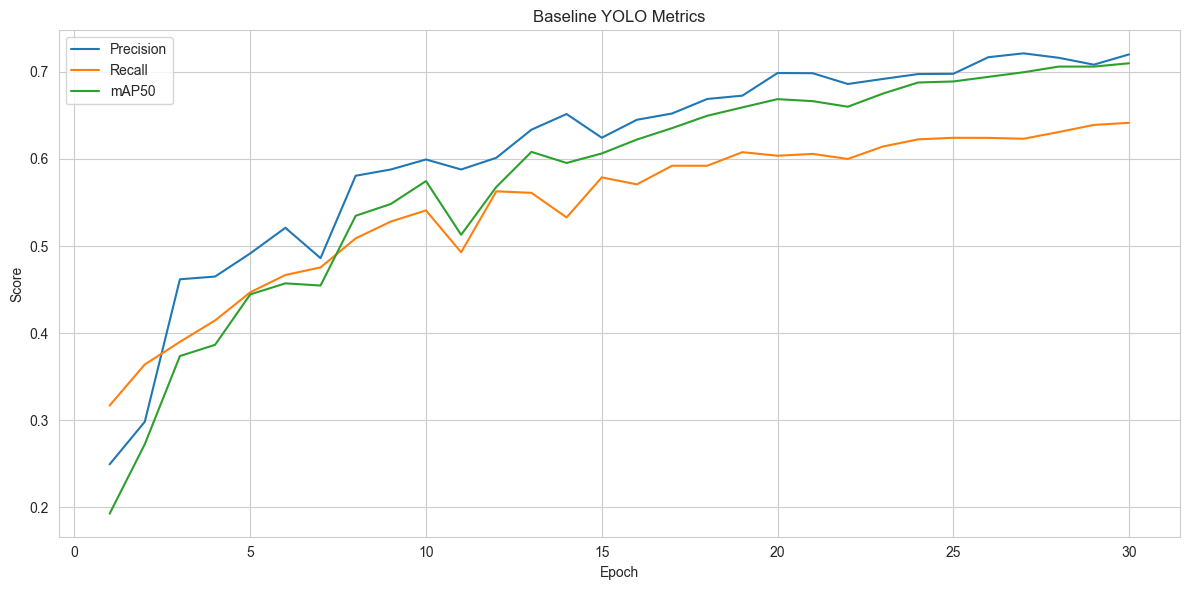

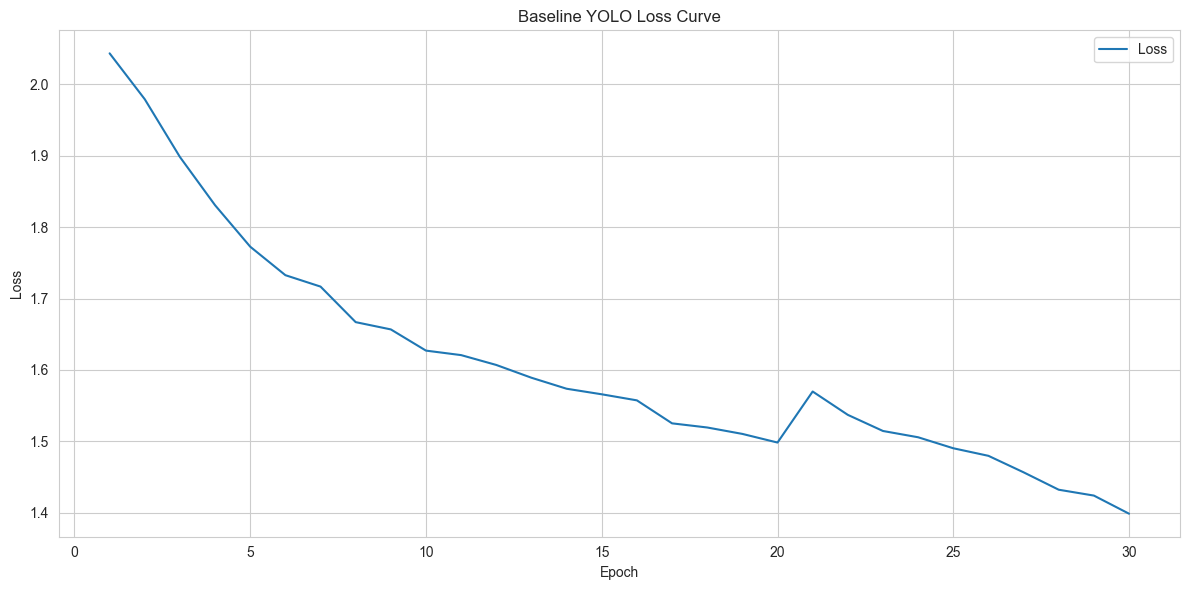

In [27]:
df = pd.read_csv(RESULTS_CSV)

# Precision / Recall / mAP50 곡선
plt.figure(figsize=(12, 6))
plt.plot(df['Epochs'], df['Precision'], label='Precision')
plt.plot(df['Epochs'], df['Recall'], label='Recall')
plt.plot(df['Epochs'], df['mAP50'], label='mAP50')

plt.title('Baseline YOLO Metrics')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

# Loss 곡선
plt.figure(figsize=(12, 6))
plt.plot(df['Epochs'], df['Loss'], label='Loss')

plt.title('Baseline YOLO Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

파트 나 + 다 공통: 모델별 예측 결과 수집

In [ ]:
analysis_rows = []
conf_rows = []

for img_path in image_paths:
    label_path = os.path.join(LABEL_DIR, Path(img_path).stem + '.txt')
    gt_boxes = load_yolo_labels(label_path)
    gt_classes = [g['class_name'] for g in gt_boxes]

    for model_name, model in models.items():
        try:
            result = model(img_path, conf=0.25, verbose=False)[0]
            preds = get_predictions(result)
            pred_classes = [p['class_name'] for p in preds]

            row = {
                'image': img_path,
                'model': model_name,
                'gt_classes': gt_classes,
                'pred_classes': pred_classes,
                'gt_count': len(gt_boxes),
                'pred_count': len(preds),
                'condition': label_condition(gt_classes)
            }

            row.update(classify_case(gt_classes, pred_classes))
            analysis_rows.append(row)

            for p in preds:
                conf_rows.append({
                    'image': img_path,
                    'model': model_name,
                    'class_name': p['class_name'],
                    'confidence': p['conf']
                })

        except Exception as e:
            print(f'추론 실패: {model_name}, {img_path} -> {e}')

analysis_df = pd.DataFrame(analysis_rows)
conf_df = pd.DataFrame(conf_rows)

print('analysis_df:', analysis_df.shape)
print('conf_df:', conf_df.shape)
analysis_df.head()

Loading best_general.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CUDAExecutionProvider
Loading best_int8.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CUDAExecutionProvider
analysis_df: (12396, 13)
conf_df: (16304, 4)
                                  image        model gt_classes pred_classes  \
0  dataset/data/val/images\AoF00008.jpg  baseline_pt         []           []   
1  dataset/data/val/images\AoF00008.jpg       opt_pt         []           []   
2  dataset/data/val/images\AoF00008.jpg    onnx_fp32         []           []   
3  dataset/data/val/images\AoF00008.jpg    onnx_int8         []           []   
4  dataset/data/val/images\AoF00009.jpg  baseline_pt         []           []   

   gt_count  pred_count condition  success_smoke  success_fire  fn_smoke  \
0         0           0      none          False         False     False   
1         0           0      none          False         False     False   
2         0           0      no

In [16]:
analysis_df = pd.DataFrame(analysis_rows)
conf_df = pd.DataFrame(conf_rows)

print('analysis_df:', analysis_df.shape)
print('conf_df:', conf_df.shape)
analysis_df.head()

analysis_df: (12396, 13)
conf_df: (16304, 4)


,image,model,gt_classes,pred_classes,gt_count,pred_count,condition,success_smoke,success_fire,fn_smoke,fn_fire,fp_smoke,fp_fire
0,dataset/data/val/images\AoF00008.jpg,baseline_pt,[],[],0,0,none,False,False,False,False,False,False
1,dataset/data/val/images\AoF00008.jpg,opt_pt,[],[],0,0,none,False,False,False,False,False,False
2,dataset/data/val/images\AoF00008.jpg,onnx_fp32,[],[],0,0,none,False,False,False,False,False,False
3,dataset/data/val/images\AoF00008.jpg,onnx_int8,[],[],0,0,none,False,False,False,False,False,False
4,dataset/data/val/images\AoF00009.jpg,baseline_pt,[],[],0,0,none,False,False,False,False,False,False


성공/실패 사례 갤러리

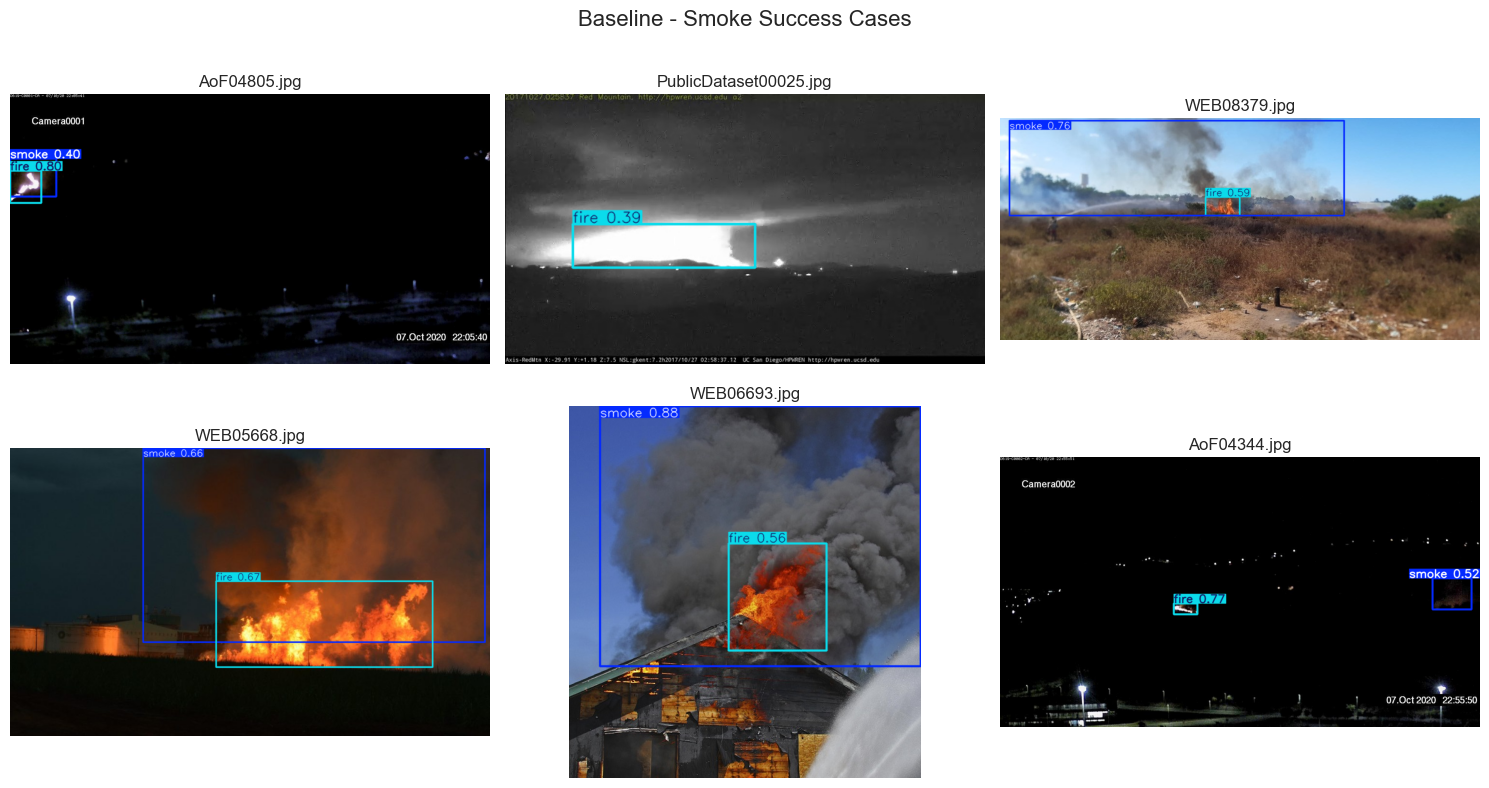

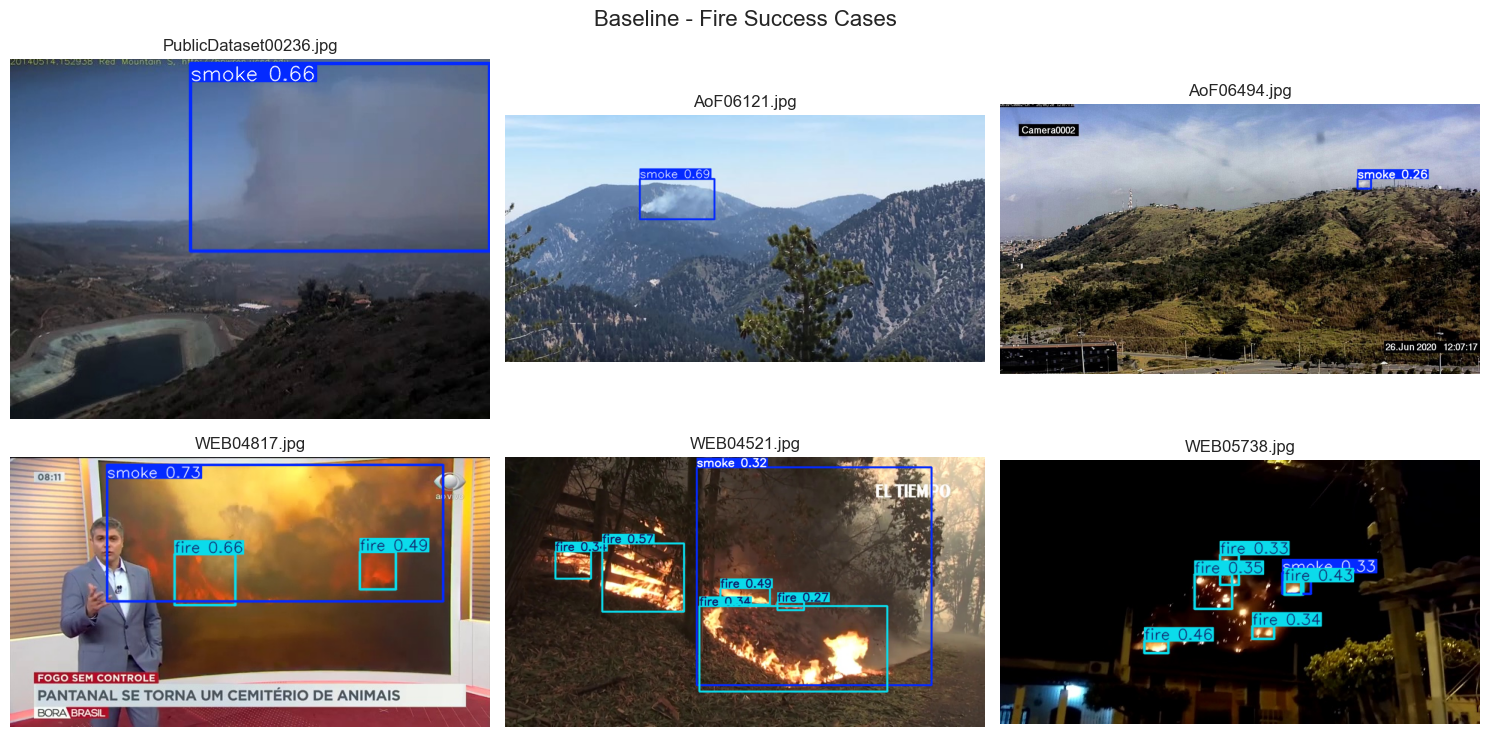

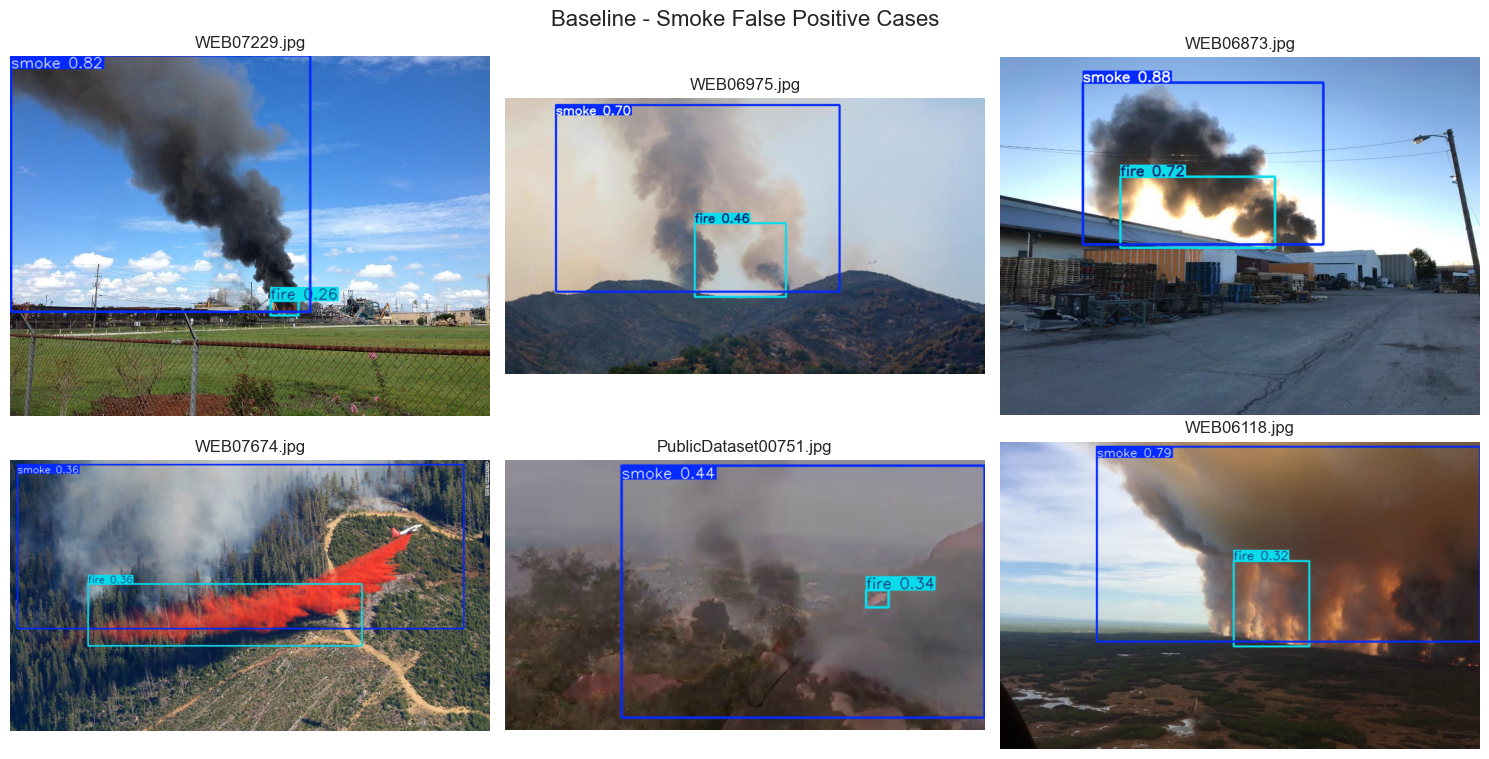

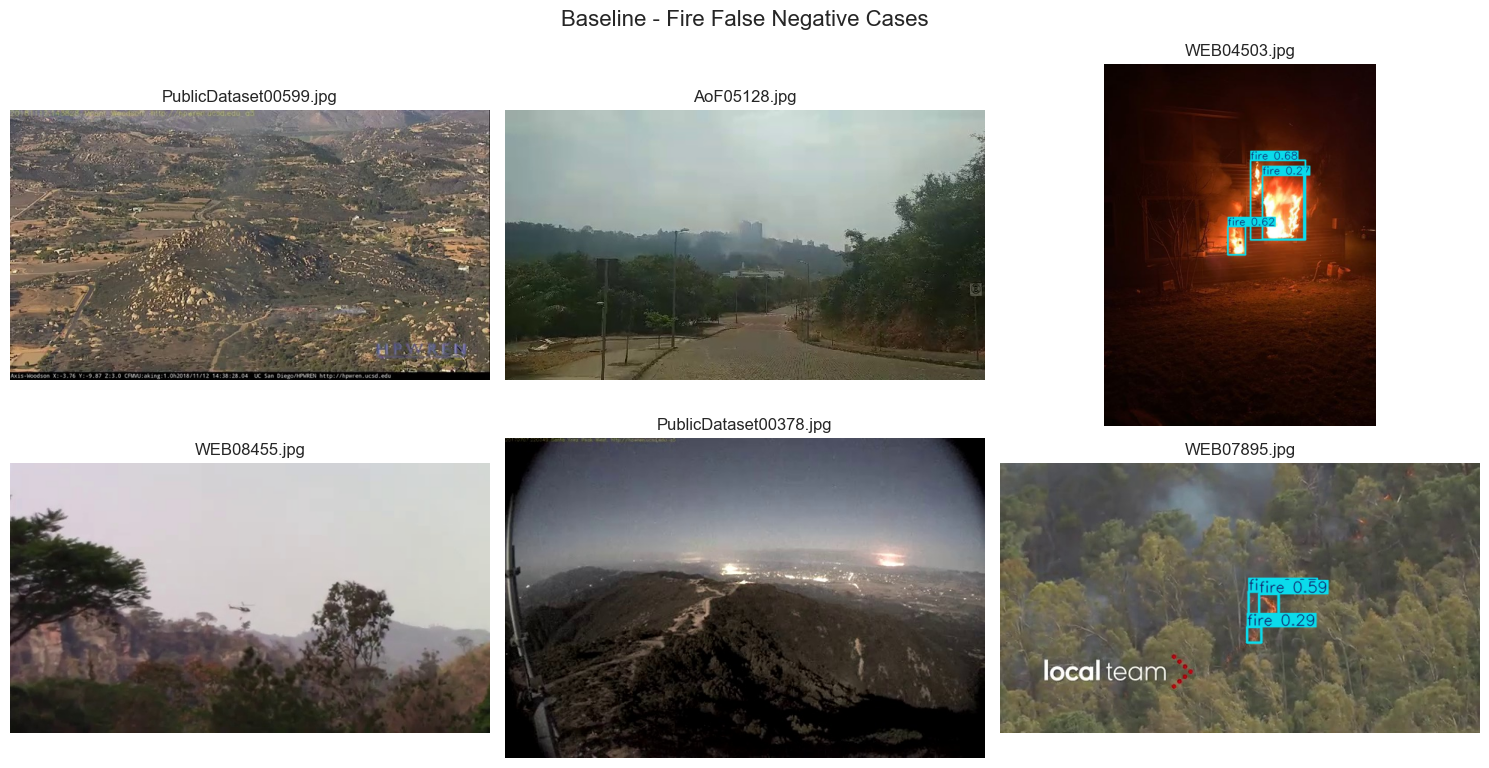

In [8]:
baseline_df = analysis_df[analysis_df['model'] == 'baseline_pt'].copy()
baseline_model = models['baseline_pt']

show_case_gallery_single_model(baseline_df, baseline_model, 'success_smoke', 'Baseline - Smoke Success Cases')
show_case_gallery_single_model(baseline_df, baseline_model, 'success_fire', 'Baseline - Fire Success Cases')
show_case_gallery_single_model(baseline_df, baseline_model, 'fp_smoke', 'Baseline - Smoke False Positive Cases')
show_case_gallery_single_model(baseline_df, baseline_model, 'fn_fire', 'Baseline - Fire False Negative Cases')

##### 모델별 같은 이미지 결과 비교 갤러리(파트 다 핵심 시각화)

이걸로 볼 수 있는 것
- 같은 이미지에서 어떤 모델이 fire를 놓치는지
- INT8에서 bbox가 줄거나 confidence가 떨어지는지
- TensorRT 결과가 baseline과 거의 같은지

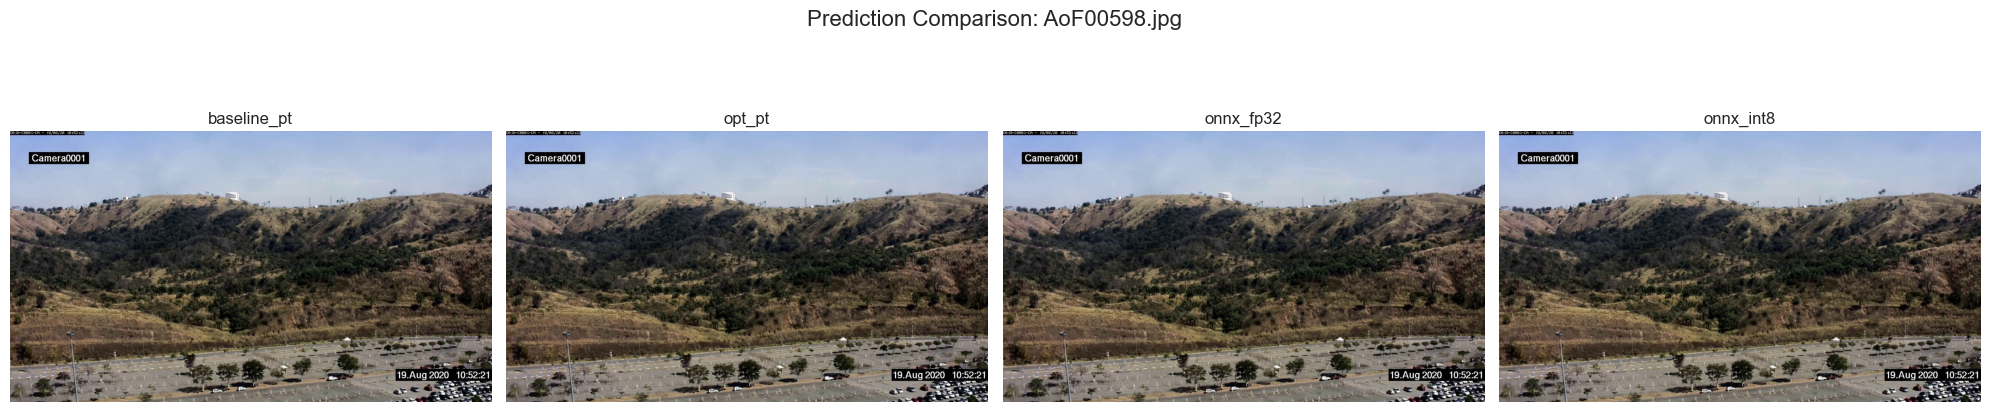

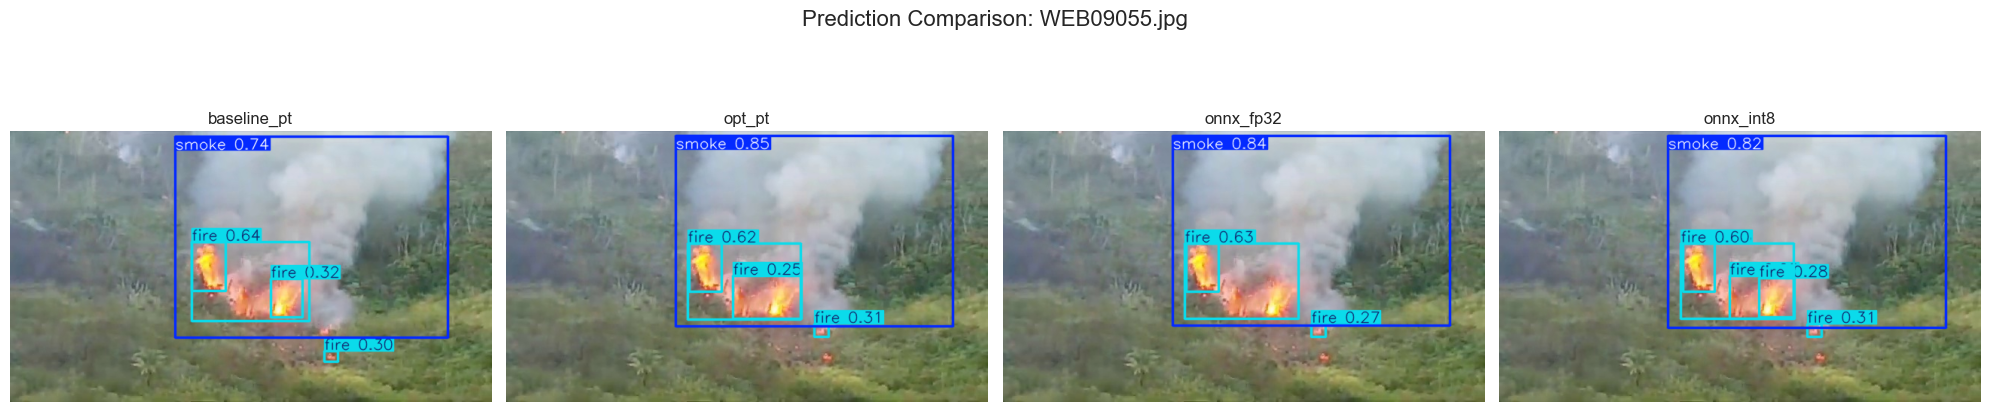

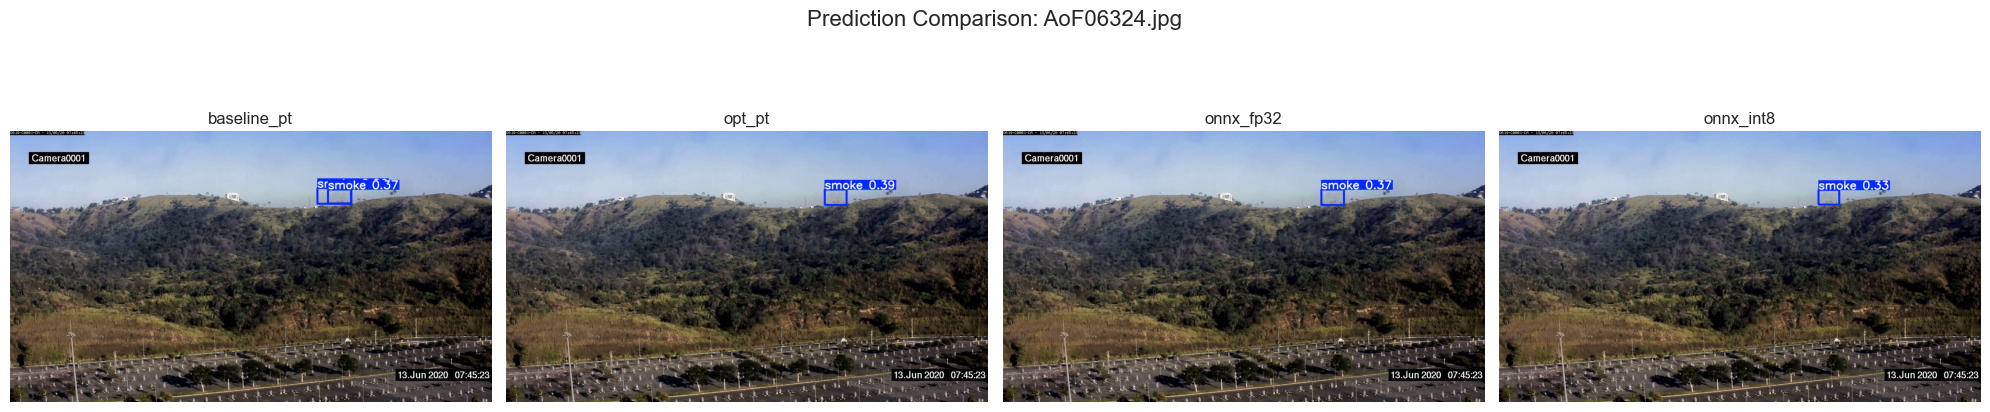

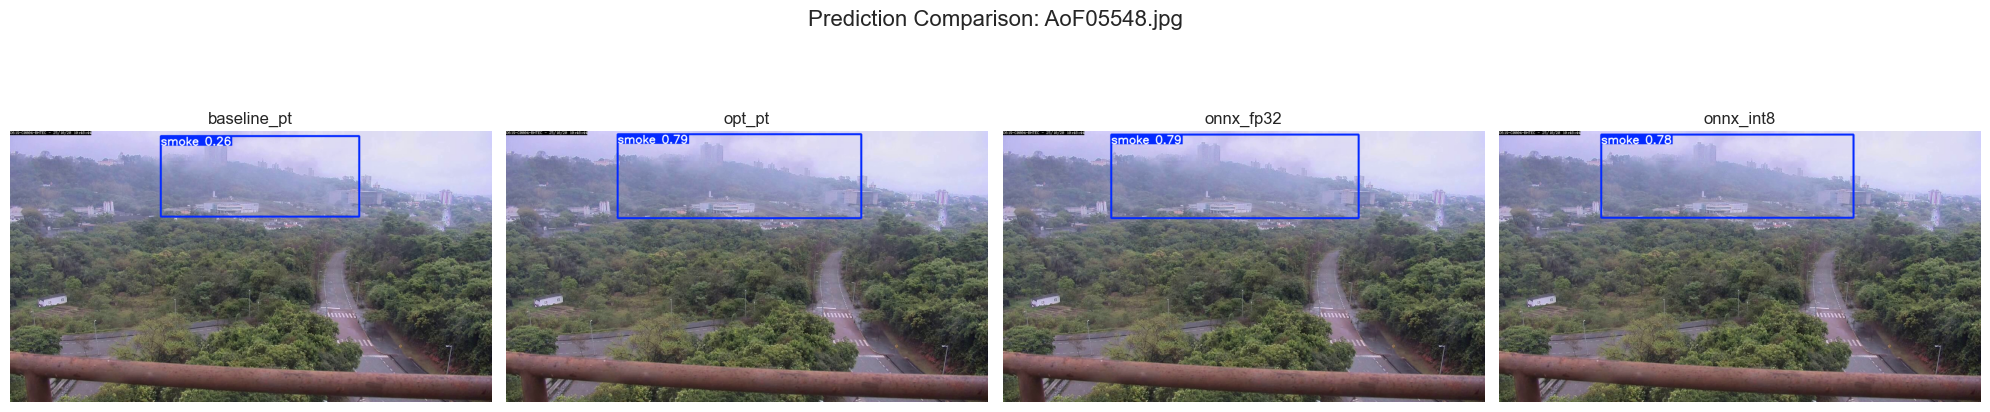

In [9]:
sample_paths = random.sample(image_paths, min(4, len(image_paths)))

for img_path in sample_paths:
    n_models = len(models)
    fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 5))

    if n_models == 1:
        axes = [axes]

    for ax, (model_name, model) in zip(axes, models.items()):
        try:
            result = model(img_path, conf=0.25, verbose=False)[0]
            plotted = result.plot()
            plotted = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)
            ax.imshow(plotted)
            ax.set_title(model_name)
            ax.axis('off')
        except Exception as e:
            ax.text(0.5, 0.5, f'Error\n{model_name}', ha='center', va='center')
            ax.axis('off')

    plt.suptitle(f'Prediction Comparison: {Path(img_path).name}', fontsize=16)
    plt.tight_layout()
    plt.show()

모델별 confidence 분포 비교

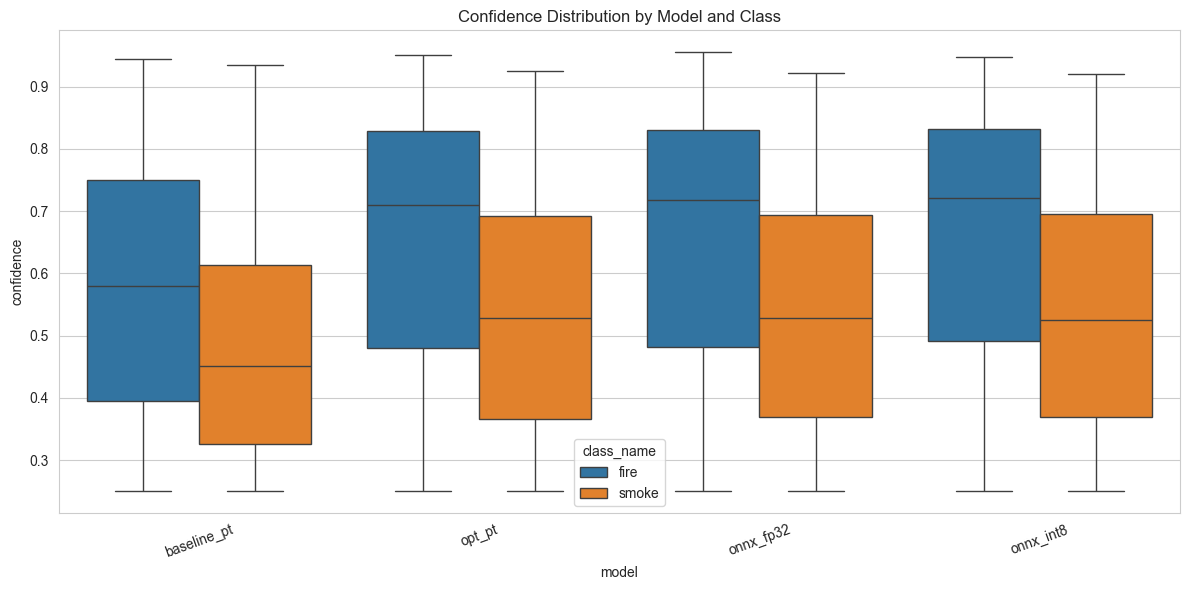

In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=conf_df, x='model', y='confidence', hue='class_name')
plt.title('Confidence Distribution by Model and Class')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

##### 모델별 FP/FN 비교

해석 포인트
- 어떤 모델이 FN_fire가 제일 많은지
- INT8 양자화 후 smoke FP가 늘었는지
- ONNX FP32는 baseline과 유사한지

In [12]:
error_summary = []

for model_name in analysis_df['model'].unique():
    temp = analysis_df[analysis_df['model'] == model_name]
    error_summary.append({
        'model': model_name,
        'FP_smoke': int(temp['fp_smoke'].sum()),
        'FP_fire': int(temp['fp_fire'].sum()),
        'FN_smoke': int(temp['fn_smoke'].sum()),
        'FN_fire': int(temp['fn_fire'].sum())
    })

error_df = pd.DataFrame(error_summary)
error_df

,model,FP_smoke,FP_fire,FN_smoke,FN_fire
0,baseline_pt,40,87,86,199
1,opt_pt,36,69,46,86
2,onnx_fp32,36,72,40,76
3,onnx_int8,34,69,42,97


##### 모델별 조건별 오류 heatmap

해석 포인트
- fire_only에서 fn_fire가 높은 모델이 누구인지
- both 상황에서 어떤 모델이 가장 불안정한지

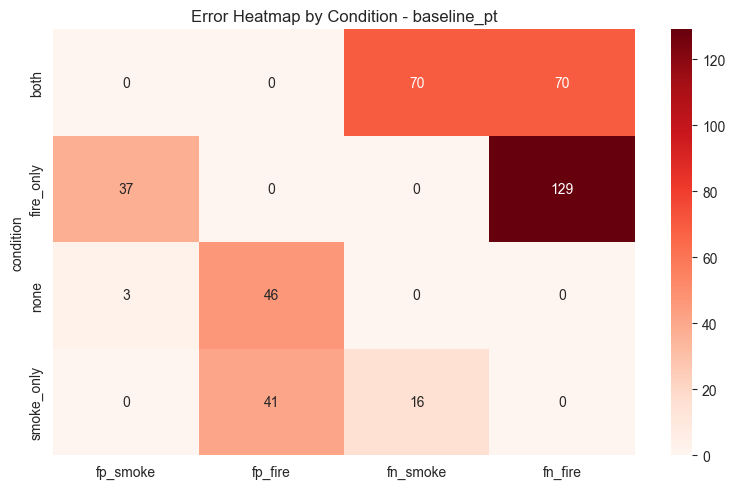

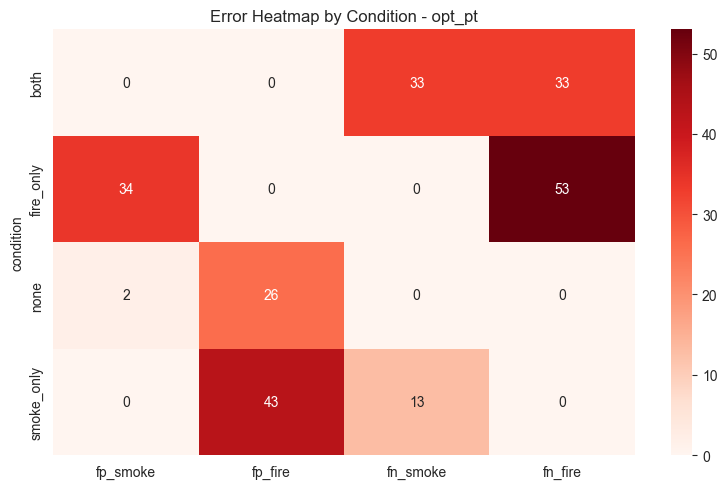

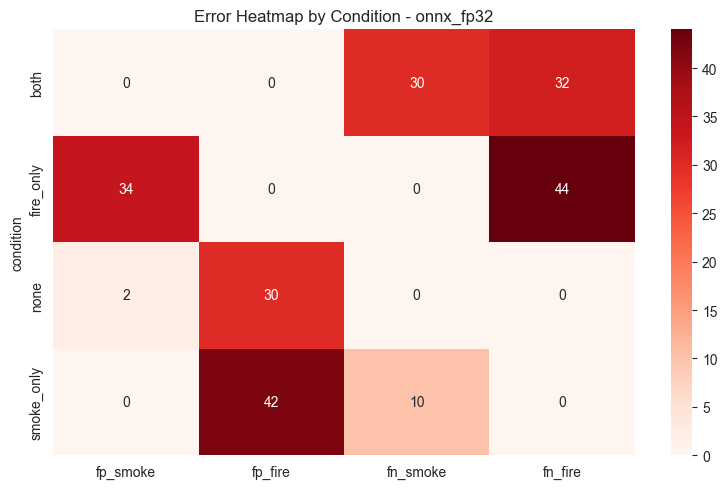

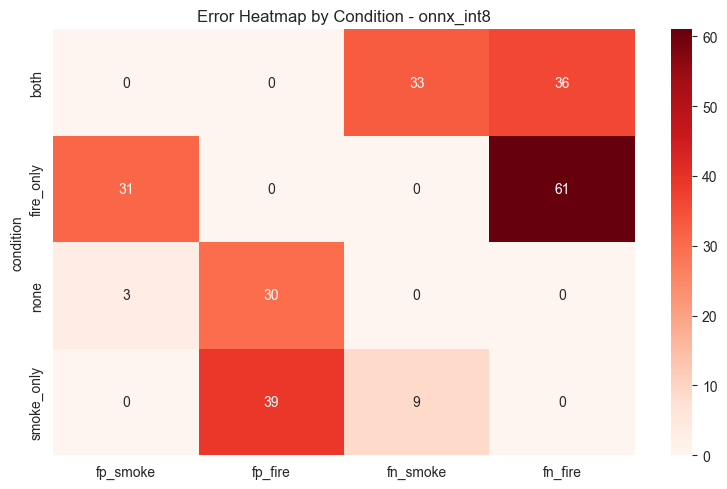

In [13]:
for model_name in analysis_df['model'].unique():
    temp = analysis_df[analysis_df['model'] == model_name]
    condition_summary = temp.groupby('condition')[['fp_smoke', 'fp_fire', 'fn_smoke', 'fn_fire']].sum()

    plt.figure(figsize=(8, 5))
    sns.heatmap(condition_summary, annot=True, fmt='d', cmap='Reds')
    plt.title(f'Error Heatmap by Condition - {model_name}')
    plt.tight_layout()
    plt.show()

baseline 대비 달라진 사례 찾기(최적화로 인해 결과가 바뀐 대표 사례)
- 예시: baseline은 fire를 맞췄는데 INT8은 놓친 경우

In [14]:
baseline_name = 'baseline_pt'
compare_name = 'onnx_int8'   # 바꿔가며 사용 가능

base_df = analysis_df[analysis_df['model'] == baseline_name][['image', 'success_fire', 'success_smoke', 'fn_fire', 'fn_smoke']]
comp_df = analysis_df[analysis_df['model'] == compare_name][['image', 'success_fire', 'success_smoke', 'fn_fire', 'fn_smoke']]

merged = base_df.merge(comp_df, on='image', suffixes=('_base', '_comp'))

changed_cases = merged[
    (merged['success_fire_base'] == True) &
    (merged['fn_fire_comp'] == True)
]

changed_cases.head()

,image,success_fire_base,success_smoke_base,fn_fire_base,fn_smoke_base,success_fire_comp,success_smoke_comp,fn_fire_comp,fn_smoke_comp
926,dataset/data/val/images\AoF05178.jpg,True,False,False,False,False,False,True,False
1053,dataset/data/val/images\AoF05873.jpg,True,False,False,False,False,False,True,False
1084,dataset/data/val/images\AoF06072.jpg,True,False,False,False,False,False,True,False
1120,dataset/data/val/images\AoF06311.jpg,True,False,False,False,False,False,True,False
1150,dataset/data/val/images\AoF06479.jpg,True,False,False,False,False,False,True,False


대표 사례 시각화

이걸로 말할 수 있는 것
- 최적화 후 small fire가 사라졌는지
- smoke는 남는데 fire만 없어졌는지

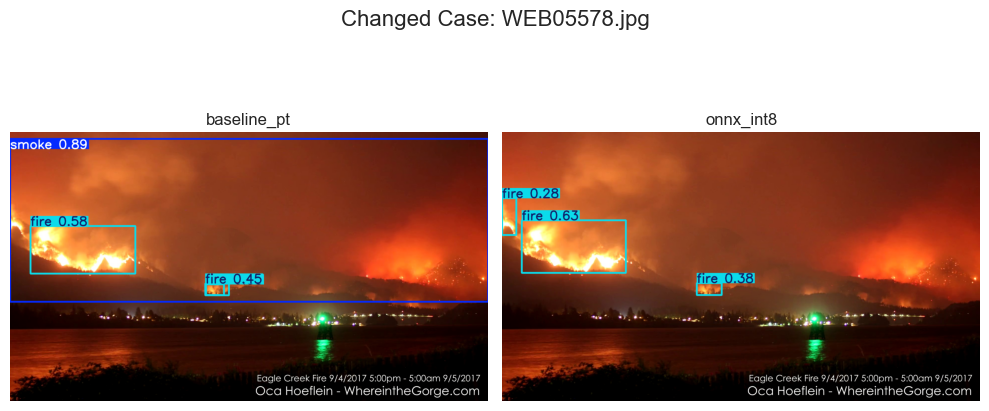

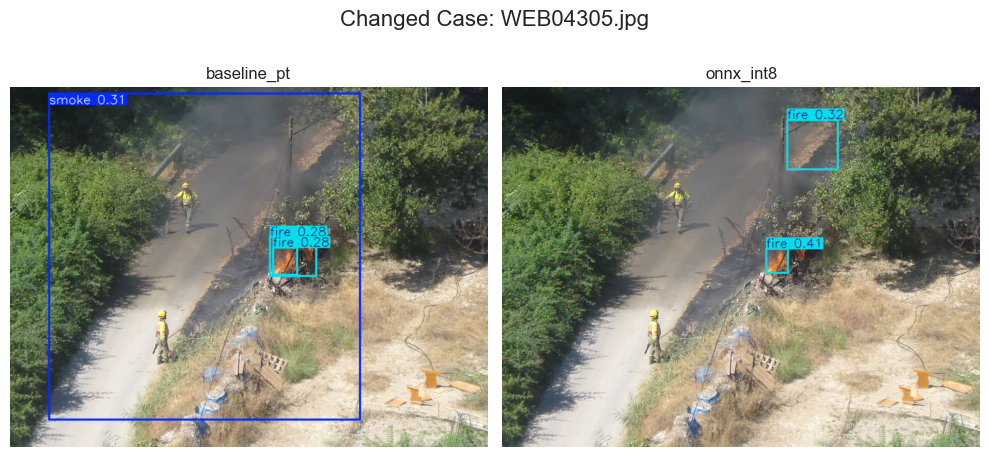

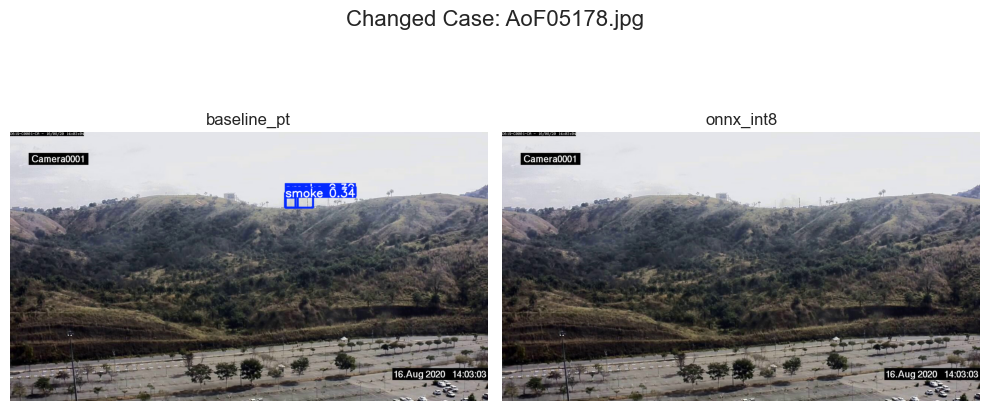

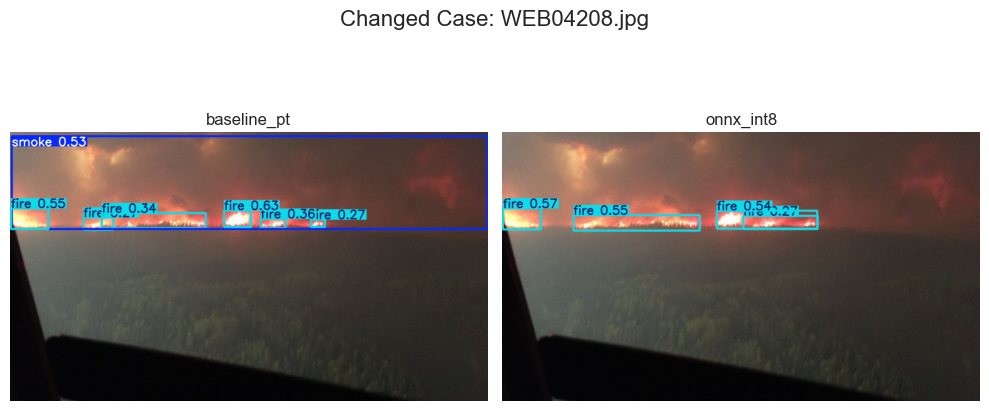

In [15]:
sample_changed = changed_cases.sample(min(4, len(changed_cases)), random_state=42)

for _, row in sample_changed.iterrows():
    img_path = row['image']

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    for ax, model_name in zip(axes, [baseline_name, compare_name]):
        result = models[model_name](img_path, conf=0.25, verbose=False)[0]
        plotted = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
        ax.imshow(plotted)
        ax.set_title(model_name)
        ax.axis('off')

    plt.suptitle(f'Changed Case: {Path(img_path).name}', fontsize=16)
    plt.tight_layout()
    plt.show()